# GRU · 04 Exploratory Data Analysis

Explores the training data: class balance, review length, negation, the words that separate the classes, and a length-only shortcut check. **Saves:** `gru_eda_class_balance.png`, `gru_eda_distinctive_words.png`.

*Notebook 4 of 14 · Previous: 03 Dataset and Split · Next: 05 Feature Engineering*

## Setup (the same in every notebook)

Each notebook in this project is self-contained. The cells below define the group settings and only the helper functions this notebook uses. They are identical in every notebook and nothing is imported from another file, so the notebook also runs on its own, for example in Colab.

In [1]:
# ---- Imports, project folders and dataset location ----------------------------------------------
import sys, re, json, time, pathlib, textwrap
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from tensorflow import keras
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)

layers = keras.layers
IN_COLAB = "google.colab" in sys.modules

# GRU_ROOT is the folder that holds the numbered step folders (01_Setup, 02_Data_Audit, ...).
# If this notebook is opened on its own (for example in Colab), the current folder is used instead.
here = pathlib.Path.cwd().resolve()
GRU_ROOT = next((p for p in [here, *here.parents] if (p / "01_Setup").is_dir()), here)
RESULTS = GRU_ROOT / "results"              # figures, metrics, predictions and trained models are saved here
RESULTS.mkdir(exist_ok=True)

# The dataset is the only input file.
DATA_NAME = "deceptive-opinion.csv"
search_in = [GRU_ROOT, GRU_ROOT / "dataset", GRU_ROOT.parent / "dataset", here, here / "dataset",
             pathlib.Path("/content")]
DATA_PATH = next((d / DATA_NAME for d in search_in if (d / DATA_NAME).exists()), None)

if DATA_PATH is None and IN_COLAB:
    from google.colab import files
    print(f"Please choose {DATA_NAME} from your computer...")
    uploaded = files.upload()                       # saved in the current folder
    DATA_PATH = here / next(iter(uploaded))
if DATA_PATH is None:
    raise FileNotFoundError(f"Cannot find {DATA_NAME}. Put it in a 'dataset' folder next to the step folders "
                            "(or next to this notebook) and run this cell again.")

print("Dataset:", DATA_PATH)
print("Results folder:", RESULTS)

Dataset: /Users/akalanka/Documents/GitHub/Deep_Learning_Assignment/Deep-Learning---Assignment-/dataset/deceptive-opinion.csv
Results folder: /Users/akalanka/Documents/GitHub/Deep_Learning_Assignment/Deep-Learning---Assignment-/gru/results


In [2]:
# ---- Group settings: identical for Simple RNN, LSTM, GRU and 1D CNN ------------------------------
SEED = 42

# Labels: this dataset has no star rating, so the `polarity` column is the label.
LABEL_COLUMN = "polarity"
LABEL_MAP = {"negative": 0, "positive": 1}

# Text -> integer sequences
VOCAB_SIZE = 5000          # total ids, including <PAD>=0 and <OOV>=1
MAX_LEN = 300              # tokens per review after cleaning
PAD_TOKEN, OOV_TOKEN = "<PAD>", "<OOV>"
PADDING = "pre"            # zeros in front, so a recurrent layer ends on real words
TRUNCATING = "post"        # long reviews keep their first MAX_LEN tokens

# Training
EMBED_DIM = 64
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5               # EarlyStopping patience, monitoring validation loss
MONITOR = "val_loss"
THRESHOLD = 0.5            # probability cut-off used for every model's test metrics

# Fixed 80/10/10 split (stratified on the label, seed 42, made after removing duplicates).
# Numbers are 0-based row positions in deceptive-opinion.csv. Every row not listed here is a TRAINING row.
# All four models must use exactly these two lists.
VAL_IDS = {
    3, 4, 6, 7, 14, 24, 25, 27, 33, 38, 46, 50, 60, 66, 72, 74, 77, 85, 89, 92, 106, 110, 112, 136,
    144, 172, 211, 215, 224, 230, 238, 242, 248, 252, 288, 302, 311, 319, 336, 345, 368, 376, 385,
    393, 402, 404, 434, 440, 442, 465, 473, 510, 512, 515, 517, 524, 533, 536, 542, 549, 553, 558,
    579, 581, 594, 603, 624, 630, 638, 644, 645, 661, 663, 665, 699, 713, 729, 754, 760, 788, 801,
    813, 820, 821, 827, 832, 840, 864, 873, 893, 897, 900, 904, 907, 908, 923, 930, 936, 962, 963,
    989, 991, 1002, 1008, 1017, 1043, 1045, 1054, 1073, 1098, 1112, 1119, 1134, 1143, 1170, 1189,
    1191, 1201, 1239, 1258, 1262, 1263, 1264, 1270, 1280, 1295, 1308, 1309, 1314, 1328, 1344, 1350,
    1359, 1360, 1364, 1367, 1368, 1369, 1370, 1377, 1378, 1381, 1418, 1423, 1450, 1467, 1479, 1480,
    1490, 1505, 1506, 1522, 1547, 1551, 1552, 1573, 1578, 1588, 1593, 1594
}
TEST_IDS = {
    0, 2, 5, 9, 39, 45, 47, 55, 108, 117, 120, 125, 138, 139, 145, 171, 191, 193, 213, 222, 227,
    228, 232, 256, 258, 260, 272, 273, 276, 281, 299, 314, 321, 325, 349, 362, 364, 391, 409, 424,
    436, 445, 467, 469, 484, 502, 503, 505, 507, 523, 525, 531, 545, 547, 572, 573, 605, 606, 612,
    622, 623, 633, 669, 671, 681, 687, 691, 698, 718, 725, 731, 741, 752, 753, 765, 770, 771, 779,
    784, 785, 804, 814, 834, 835, 847, 852, 859, 866, 882, 887, 889, 901, 932, 940, 958, 961, 968,
    972, 993, 1003, 1007, 1019, 1020, 1033, 1044, 1046, 1055, 1072, 1076, 1079, 1091, 1117, 1141,
    1147, 1149, 1151, 1176, 1182, 1183, 1193, 1195, 1196, 1205, 1210, 1217, 1222, 1231, 1259, 1265,
    1275, 1278, 1279, 1288, 1293, 1296, 1302, 1306, 1312, 1324, 1357, 1365, 1366, 1396, 1404, 1416,
    1446, 1451, 1465, 1478, 1485, 1487, 1492, 1503, 1504, 1516, 1524, 1540, 1562, 1582, 1597
}
keras.utils.set_random_seed(SEED)          # seeds Python, NumPy and TensorFlow
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| seed", SEED)
print("Devices:", [d.device_type for d in tf.config.list_physical_devices()])

TensorFlow 2.21.0 | Keras 3.15.1 | seed 42
Devices: ['CPU']


In [3]:
# ---- Data pipeline: load -> label -> de-duplicate -> split -> clean -> vocabulary -> pad ----------
# Leakage rule: the vocabulary and the class weights are built from TRAINING rows only.
# Validation and test rows are only ever encoded with the training vocabulary.

def load_labelled_data() -> pd.DataFrame:
    """Read the CSV, map polarity -> 0/1 and drop exact duplicate reviews.

    Duplicates must go before splitting, otherwise a copy of a training review could land in the
    test set and the test set would no longer be unseen.
    """
    df = pd.read_csv(DATA_PATH)
    df["row_id"] = np.arange(len(df))                   # 0-based row number in the CSV
    df["text"] = df["text"].astype(str).str.strip()
    df["label"] = df[LABEL_COLUMN].map(LABEL_MAP)
    assert df["label"].notna().all(), "unexpected label value"
    df["label"] = df["label"].astype(int)
    df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)
    return df[["row_id", "text", "label", "hotel", "deceptive", "source"]]


def assign_split(df: pd.DataFrame) -> np.ndarray:
    """'train' / 'val' / 'test' for every row, from the fixed id lists above."""
    if not (VAL_IDS | TEST_IDS) <= set(df["row_id"]):
        raise ValueError("The fixed validation/test ids do not match this dataset. Was the CSV changed?")
    return np.where(df["row_id"].isin(TEST_IDS), "test",
                    np.where(df["row_id"].isin(VAL_IDS), "val", "train"))


# Text cleaning: identical for all models; a pure per-review function, nothing is fitted.
_HTML = re.compile(r"<[^>]+>")
_URL = re.compile(r"(https?://\S+|www\.\S+)")
_CONTRACTIONS = [                       # keep negation: "didn't" -> "did not", not "didn t"
    (r"\bwon't\b", "will not"), (r"\bcan't\b", "can not"), (r"\bcannot\b", "can not"),
    (r"n't\b", " not"), (r"'re\b", " are"), (r"'ve\b", " have"), (r"'ll\b", " will"),
    (r"'d\b", " would"), (r"'m\b", " am"), (r"'s\b", ""),
]
_NON_LETTER = re.compile(r"[^a-z\s]")
_SPACES = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """lowercase -> strip HTML -> strip URLs -> expand contractions -> keep letters only.

    Stop-words are deliberately NOT removed: words such as "not", "no" and "never" flip the sentiment.
    """
    text = text.lower().replace("’", "'")
    text = _HTML.sub(" ", text)
    text = _URL.sub(" ", text)
    for pattern, replacement in _CONTRACTIONS:
        text = re.sub(pattern, replacement, text)
    text = _NON_LETTER.sub(" ", text)           # digits, punctuation, symbols
    return _SPACES.sub(" ", text).strip()


def build_vocab(train_token_lists, vocab_size: int = VOCAB_SIZE) -> dict:
    """Most frequent TRAINING words -> ids. 0 = <PAD>, 1 = <OOV>, real words start at 2."""
    counts = Counter(tok for tokens in train_token_lists for tok in tokens)
    words = [w for w, _ in counts.most_common(vocab_size - 2)]
    vocab = {PAD_TOKEN: 0, OOV_TOKEN: 1}
    vocab.update({w: i + 2 for i, w in enumerate(words)})
    return vocab


def encode(tokens, vocab: dict) -> list:
    oov = vocab[OOV_TOKEN]
    return [vocab.get(t, oov) for t in tokens]


def decode(ids, vocab: dict, skip_pad: bool = True) -> list:
    """Inverse of `encode`: ids -> words. Unknown words come back as <OOV> (the original is lost)."""
    inverse = {i: w for w, i in vocab.items()}
    return [inverse[int(i)] for i in ids if not (skip_pad and int(i) == 0)]


def pad(sequences, max_len: int = MAX_LEN) -> np.ndarray:
    out = np.zeros((len(sequences), max_len), dtype="int32")
    for i, seq in enumerate(sequences):
        seq = seq[:max_len] if TRUNCATING == "post" else seq[-max_len:]
        if PADDING == "pre":
            out[i, max_len - len(seq):] = seq
        else:
            out[i, :len(seq)] = seq
    return out


def compute_class_weights(y_train) -> dict:
    """weight_c = n_samples / (n_classes * n_samples_in_class_c)   (same as sklearn 'balanced')."""
    classes, counts = np.unique(y_train, return_counts=True)
    return {int(c): float(len(y_train) / (len(classes) * n)) for c, n in zip(classes, counts)}


@dataclass
class Data:
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    vocab: dict
    class_weight: dict
    train_df: pd.DataFrame     # raw + cleaned text, kept for EDA / error analysis
    val_df: pd.DataFrame
    test_df: pd.DataFrame


def prepare_data() -> Data:
    """Everything a model needs, in one call."""
    df = load_labelled_data()
    df["split"] = assign_split(df)
    df["clean"] = df["text"].map(clean_text)
    df["tokens"] = df["clean"].str.split()

    parts = {name: g.reset_index(drop=True) for name, g in df.groupby("split")}
    vocab = build_vocab(parts["train"]["tokens"].tolist())          # <- TRAIN ONLY

    def to_xy(part: pd.DataFrame):
        seqs = [encode(tokens, vocab) for tokens in part["tokens"]]
        return pad(seqs), part["label"].to_numpy(dtype="int32")

    X_train, y_train = to_xy(parts["train"])
    X_val, y_val = to_xy(parts["val"])
    X_test, y_test = to_xy(parts["test"])
    return Data(X_train, y_train, X_val, y_val, X_test, y_test, vocab,
                compute_class_weights(y_train), parts["train"], parts["val"], parts["test"])

In [4]:
# ---- Plot helpers: same figure style for all models -----------------------------------------------
# White background, thin lines, light grid, no top/right frame, text in neutral ink, legend for 2+ series.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
BLUE_RAMP = LinearSegmentedColormap.from_list("blue_seq", ["#cde2fb", "#3987e5", "#0d366b"])

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.edgecolor": GRID, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save_and_show(fig, path=None, show=True):
    fig.tight_layout()
    if path:
        fig.savefig(path)
    if show:
        plt.show()
    plt.close(fig)


def plot_curve(history: dict, metric: str, model_name: str, best_epoch=None, path=None, show=True):
    """Training vs validation curve for 'accuracy' or 'loss'."""
    train, val = history[metric], history["val_" + metric]
    epochs = np.arange(1, len(train) + 1)
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(epochs, train, color=BLUE, label="Training")
    ax.plot(epochs, val, color=ORANGE, label="Validation")
    for series, color, name in ((train, BLUE, "Training"), (val, ORANGE, "Validation")):
        ax.plot(epochs[-1], series[-1], "o", color=color, markersize=6,
                markeredgecolor="white", markeredgewidth=1.5)
        ax.annotate(name, (epochs[-1], series[-1]), xytext=(8, 0), textcoords="offset points",
                    va="center", color=INK2, fontsize=10)
    if best_epoch:
        ax.axvline(best_epoch, color=INK2, linestyle=":", linewidth=1.2)
        ax.text(best_epoch, ax.get_ylim()[1], f" best epoch {best_epoch}", color=INK2,
                fontsize=9, va="top", ha="left")
    ax.set_xlim(0.7, epochs[-1] + 0.15 * max(epochs[-1], 6))
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"{model_name}: training vs validation {metric}", loc="left")
    ax.legend(loc="best")
    save_and_show(fig, path, show)


def plot_confusion_matrix(cm: np.ndarray, model_name: str, path=None, show=True):
    """2x2 confusion matrix (rows = true class, columns = predicted class)."""
    labels = ["Negative", "Positive"]
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    ax.imshow(cm, cmap=BLUE_RAMP, vmin=0, vmax=cm.max())
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            dark = cm[i, j] > cm.max() * 0.55
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=18,
                    fontweight="bold", color="white" if dark else INK)
    ax.set_xticks([0, 1], labels)
    ax.set_yticks([0, 1], labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_name}: confusion matrix (test)", loc="left")
    for s in ax.spines.values():
        s.set_visible(False)
    save_and_show(fig, path, show)


def plot_roc(y_true, y_prob, auc: float, model_name: str, threshold: float = 0.5, path=None, show=True):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(5.2, 4.8))
    ax.plot([0, 1], [0, 1], color=INK2, linestyle="--", linewidth=1.2)
    ax.text(0.55, 0.47, "chance (AUC = 0.50)", color=INK2, fontsize=9, rotation=33)
    ax.plot(fpr, tpr, color=BLUE)
    k = np.argmin(np.abs(thr - threshold))          # operating point at the 0.5 cut-off
    ax.plot(fpr[k], tpr[k], "o", color=ORANGE, markersize=8, markeredgecolor="white", markeredgewidth=1.5)
    ax.annotate(f"threshold {threshold}", (fpr[k], tpr[k]), xytext=(10, -14),
                textcoords="offset points", color=INK2, fontsize=9)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{model_name}: ROC curve (test), AUC = {auc:.3f}", loc="left")
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_aspect("equal")
    save_and_show(fig, path, show)


def plot_probability_hist(y_true, y_prob, model_name: str, threshold: float = 0.5, path=None, show=True):
    """How confident is the model? Predicted P(positive), split by the true class (stacked bars)."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob).ravel()
    bins = np.linspace(0, 1, 21)
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.hist([y_prob[y_true == 1], y_prob[y_true == 0]], bins=bins, stacked=True,
            color=[BLUE, ORANGE], label=["True positive reviews", "True negative reviews"],
            edgecolor="white", linewidth=1.5)
    ax.axvline(threshold, color=INK2, linestyle=":", linewidth=1.2)
    ax.set_xlabel("Predicted probability of positive")
    ax.set_ylabel("Number of test reviews")
    ax.set_title(f"{model_name}: confidence on the test set", loc="left")
    ax.legend(loc="upper center")
    save_and_show(fig, path, show)

### Load what this notebook needs

In [5]:
data = prepare_data()      # same data, split and vocabulary in every notebook

## Exploratory data analysis (training set)

Text analysis uses the **training** set only, so nothing in the validation or test text can influence our choices.

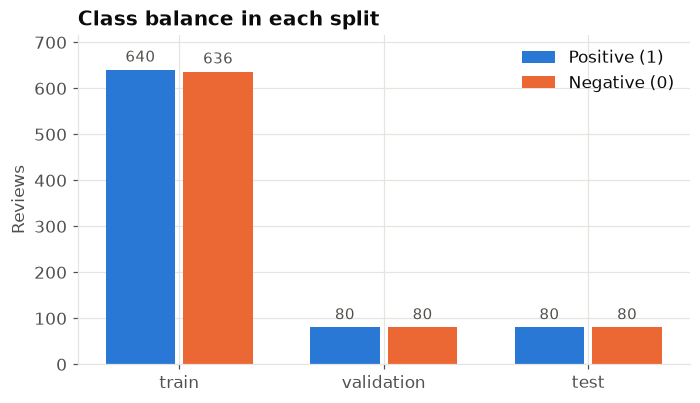

In [6]:
splits = {"train": data.y_train, "validation": data.y_val, "test": data.y_test}
x, w = np.arange(len(splits)), 0.38
pos = [int(y.sum()) for y in splits.values()]
neg = [int((1 - y).sum()) for y in splits.values()]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
b1 = ax.bar(x - w / 2, pos, w - 0.04, color=BLUE, label="Positive (1)")
b2 = ax.bar(x + w / 2, neg, w - 0.04, color=ORANGE, label="Negative (0)")
for bars in (b1, b2):
    ax.bar_label(bars, padding=3, color=INK2, fontsize=10)
ax.set_xticks(x, list(splits))
ax.set_ylabel("Reviews")
ax.set_ylim(0, max(pos + neg) * 1.12)
ax.set_title("Class balance in each split", loc="left")
ax.legend(loc="upper right")
save_and_show(fig, RESULTS / "gru_eda_class_balance.png")

In [7]:
from collections import Counter

tr = data.train_df.assign(n_tokens=lambda d: d["tokens"].map(len),
                          label_name=lambda d: d["label"].map({1: "positive", 0: "negative"}))
print("Tokens per review by class (training set):")
print(tr.groupby("label_name")["n_tokens"].describe()[["count", "mean", "50%", "max"]].round(1).to_string())

NEGATION = {"not", "no", "never", "nothing", "nobody", "none", "without"}
has_negation = tr["tokens"].map(lambda t: bool(NEGATION & set(t)))
share = tr.assign(neg=has_negation).groupby("label_name")["neg"].mean().mul(100).round(1)
print("\n% of reviews containing a negation word:", share.to_dict(),
      "\n(negations are kept, because they change the meaning of a sentence)")

print("\nReview origin x label (training set). 'deceptive' is not a model input, it is only used for error analysis:")
print(pd.crosstab(tr["label_name"], tr["deceptive"]).to_string())
print("\nMost frequent tokens (stop-words included):",
      [w for w, _ in Counter(t for toks in tr["tokens"] for t in toks).most_common(12)])

Tokens per review by class (training set):
            count   mean    50%    max
label_name                            
negative    636.0  180.4  159.0  795.0
positive    640.0  118.8  103.0  432.0

% of reviews containing a negation word: {'negative': 95.8, 'positive': 59.7} 
(negations are kept, because they change the meaning of a sentence)

Review origin x label (training set). 'deceptive' is not a model input, it is only used for error analysis:
deceptive   deceptive  truthful
label_name                     
negative          319       317
positive          322       318

Most frequent tokens (stop-words included): ['the', 'and', 'to', 'i', 'a', 'was', 'in', 'hotel', 'of', 'we', 'not', 'for']


In [8]:
# Could the model "cheat" using review length alone? Negative reviews are longer, so check how far a
# one-number length rule gets. Threshold chosen on TRAIN, scored on VALIDATION (test is not touched).
from sklearn.metrics import roc_auc_score

len_train = data.train_df["tokens"].map(len).to_numpy()
len_val = data.val_df["tokens"].map(len).to_numpy()
candidates = np.unique(len_train)
train_acc = [((len_train <= t).astype(int) == data.y_train).mean() for t in candidates]
T = candidates[int(np.argmax(train_acc))]
print(f"Length-only rule 'longer than {T} tokens -> negative': train accuracy {max(train_acc):.3f}, "
      f"validation accuracy {((len_val <= T).astype(int) == data.y_val).mean():.3f}, "
      f"validation ROC-AUC {roc_auc_score(data.y_val, -len_val):.3f}  (chance = 0.500)")

Length-only rule 'longer than 120 tokens -> negative': train accuracy 0.672, validation accuracy 0.675, validation ROC-AUC 0.703  (chance = 0.500)


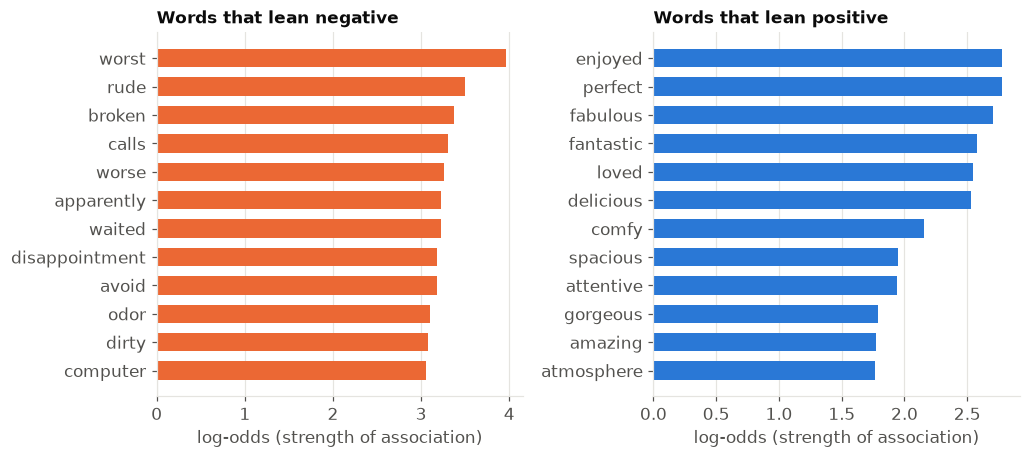

In [9]:
# Which words separate positive from negative reviews? (display only: common stop-words hidden here,
# but they are NOT removed from the model input)
STOP = set("a an the and or but of to in on at for with from by as is was were are be been am it its this that "
           "these those i me my we our you your they their he she him her them us so very just also than then "
           "there here had have has do did does would could will".split())
docs = {k: [set(t) - STOP for t in tr.loc[tr["label"] == k, "tokens"]] for k in (1, 0)}
n_docs = {k: len(v) for k, v in docs.items()}
doc_freq = {k: Counter(word for d in docs[k] for word in d) for k in (1, 0)}
score = {word: np.log((doc_freq[1][word] + 1) / (n_docs[1] + 2)) - np.log((doc_freq[0][word] + 1) / (n_docs[0] + 2))
         for word in set(doc_freq[1]) | set(doc_freq[0]) if doc_freq[1][word] + doc_freq[0][word] >= 20}
ranked = sorted(score.items(), key=lambda kv: kv[1])
panels = ((ranked[:12], ORANGE, "Words that lean negative"), (ranked[::-1][:12], BLUE, "Words that lean positive"))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.3))
for ax, (items, colour, title) in zip(axes, panels):
    words, values = zip(*items)
    ax.barh(np.arange(len(words)), np.abs(values), color=colour, height=0.65)
    ax.set_yticks(np.arange(len(words)), words)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("log-odds (strength of association)")
    ax.set_title(title, loc="left", fontsize=11)
save_and_show(fig, RESULTS / "gru_eda_distinctive_words.png")

---
*Notebook 4 of 14 · Previous: 03 Dataset and Split · Next: 05 Feature Engineering*